# Set Up

In [1]:
# In case switch to PyTorch becomes necessary
import os
os.environ['KERAS_BACKEND'] = 'tensorflow'

import numpy as np
import keras
import sentencepiece as spm

print(f"Keras version: {keras.__version__}")
print(f"Keras backend: {keras.config.backend()}")



C:\Users\Patrik\anaconda3\envs\keras\Lib\site-packages\requests\__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


Keras version: 3.14.0
Keras backend: tensorflow


In [4]:
with open('../../Datasets/Texts/Hamlet/gutenberg-hamlet-cleaned.txt', 'r', encoding='utf-8-sig') as file:
    text = file.read()

print(f"Text length: {len(text)} characters")
print(f"First 100 characters: {text[:100]}")

Text length: 176430 characters
First 100 characters: SCENE. Elsinore.




ACT I

SCENE I. Elsinore. A platform before the Castle.


Enter Francisco and B


# Building The Model

## Training SentencePiece Model

In [5]:
# Cell 3: Train SentencePiece model
# Save text to a temporary file for SentencePiece training
temp_file = 'hamlet_temp.txt'
with open(temp_file, 'w', encoding='utf-8') as f:
    f.write(text)

# Train SentencePiece model
vocab_size = 5000
model_prefix = 'hamlet_sp'

spm.SentencePieceTrainer.train(
    input=temp_file,
    model_prefix=model_prefix,
    vocab_size=vocab_size,
    character_coverage=1.0,
    model_type='bpe',
    user_defined_symbols=['<PAD>', '<UNK>']
)

# Load the trained tokenizer
sp = spm.SentencePieceProcessor()
sp.load(f"{model_prefix}.model")

# Test tokenization
test_text = "To be, or not to be, that is the question:"
tokens = sp.encode_as_pieces(test_text)
print(f"Tokenized example: {tokens}")
print(f"Vocabulary size: {sp.get_piece_size()}")

Tokenized example: ['▁To', '▁be', ',', '▁or', '▁not', '▁to', '▁be', ',', '▁that', '▁is', '▁the', '▁question', ':']
Vocabulary size: 5000


## Preparing The Data

In [6]:
# Tokenize the text
seq_length = 64
pieces = sp.encode_as_ids(text)
print(f"Total tokens: {len(pieces)}")

# Create sequences
sequences = []
for i in range(0, len(pieces) - seq_length):
    # Input: first seq_length tokens, Target: next seq_length tokens (shifted by 1)
    sequences.append(pieces[i:i+seq_length+1])

# Convert to NumPy arrays
sequences = np.array(sequences)
inputs = sequences[:, :-1]  # All tokens except the last one
targets = sequences[:, 1:]  # All tokens except the first one

print(f"Number of sequences: {len(sequences)}")
print(f"Input shape: {inputs.shape}")
print(f"Target shape: {targets.shape}")

# Split into training and validation sets
indices = np.arange(len(sequences))
np.random.shuffle(indices)

train_size = int(0.8 * len(sequences))
train_indices = indices[:train_size]
val_indices = indices[train_size:]

train_inputs, train_targets = inputs[train_indices], targets[train_indices]
val_inputs, val_targets = inputs[val_indices], targets[val_indices]

Total tokens: 45178
Number of sequences: 45114
Input shape: (45114, 64)
Target shape: (45114, 64)


In [7]:
def get_positional_encoding(max_len, d_model):
    """Create sinusoidal positional encoding."""
    positions = np.arange(max_len)[:, np.newaxis]
    angles = np.arange(d_model)[np.newaxis, :] / d_model
    angles = 1 / (10000**angles)

    pos_encoding = positions * angles
    pos_encoding[:, 0::2] = np.sin(pos_encoding[:, 0::2])
    pos_encoding[:, 1::2] = np.cos(pos_encoding[:, 1::2])

    return pos_encoding

# Define model parameters
embed_dim = 192
num_heads = 4
ff_dim = 384
num_layers = 2

# Create the model
inputs = keras.Input(shape=(seq_length,))
embedding_layer = keras.layers.Embedding(sp.get_piece_size(), embed_dim)(inputs)

# Add positional encoding
pos_encoding = get_positional_encoding(seq_length, embed_dim)
x = embedding_layer + pos_encoding

# Transformer blocks
for _ in range(num_layers):
    # Multi-head attention with causal mask
    attention_output = keras.layers.MultiHeadAttention(
        num_heads=num_heads,
        key_dim=embed_dim // num_heads,
        dropout=0.1
    )(x, x, use_causal_mask=True)

    # Add & Norm
    x = keras.layers.LayerNormalization(epsilon=1e-6)(x + attention_output)

    # Feed-forward network
    ffn = keras.Sequential([
        keras.layers.Dense(ff_dim, activation="relu"),
        keras.layers.Dense(embed_dim),
        keras.layers.Dropout(0.1)
    ])
    ffn_output = ffn(x)

    # Add & Norm
    x = keras.layers.LayerNormalization(epsilon=1e-6)(x + ffn_output)

# Final output layer
outputs = keras.layers.Dense(sp.get_piece_size())(x)

# Create model
model = keras.Model(inputs=inputs, outputs=outputs)

# Compile model
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=5e-5),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 64)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 64, 192)   │    960,000 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 64, 192)   │          0 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 64, 192)   │    148,224 │ add[0][0],        │
│ (MultiHeadAttentio… │                   │            │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 64, 192)   │          0 │ add[0][0],        │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 64, 192)   │        384 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential          │ (None, 64, 192)   │    148,032 │ layer_normalizat… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 64, 192)   │          0 │ layer_normalizat… │
│                     │                   │            │ sequential[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 64, 192)   │        384 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 64, 192)   │    148,224 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 64, 192)   │          0 │ layer_normalizat… │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 64, 192)   │        384 │ add_3[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_1        │ (None, 64, 192)   │    148,032 │ layer_normalizat… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_4 (Add)         │ (None, 64, 192)   │          0 │ layer_normalizat… │
│                     │                   │            │ sequential_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 64, 192)   │        384 │ add_4[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 64, 5000)  │    965,000 │ layer_normalizat… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,519,048 (9.61 MB)

 Trainable params: 2,519,048 (9.61 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
batch_size = 128
epochs = 10

history = model.fit(
    train_inputs, train_targets,
    validation_data=(val_inputs, val_targets),
    batch_size=batch_size,
    epochs=epochs,
    callbacks=[
        keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True, verbose=1),
        keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=1),
        keras.callbacks.ModelCheckpoint('hamlet_best_model.keras', save_best_only=True)
    ]
)

Epoch 1/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 469s 2s/step - accuracy: 0.0633 - loss: 7.2122 - val_accuracy: 0.0651 - val_loss: 6.4748 - learning_rate: 5.0000e-05
Epoch 2/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 476s 2s/step - accuracy: 0.0736 - loss: 6.3881 - val_accuracy: 0.0881 - val_loss: 6.3566 - learning_rate: 5.0000e-05
Epoch 3/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 477s 2s/step - accuracy: 0.1064 - loss: 6.2055 - val_accuracy: 0.1273 - val_loss: 5.9006 - learning_rate: 5.0000e-05
Epoch 4/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 478s 2s/step - accuracy: 0.1493 - loss: 5.6173 - val_accuracy: 0.1682 - val_loss: 5.3278 - learning_rate: 5.0000e-05
Epoch 5/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 478s 2s/step - accuracy: 0.1797 - loss: 5.1856 - val_accuracy: 0.1914 - val_loss: 4.9652 - learning_rate: 5.0000e-05
Epoch 6/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 478s 2s/step - accuracy: 0.1985 - loss: 4.8839 - val_accuracy: 0.2101 - val_loss: 4.6974 - learning_rate: 5.0000e-05
Epoch 7/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 479s 2s/step - acc

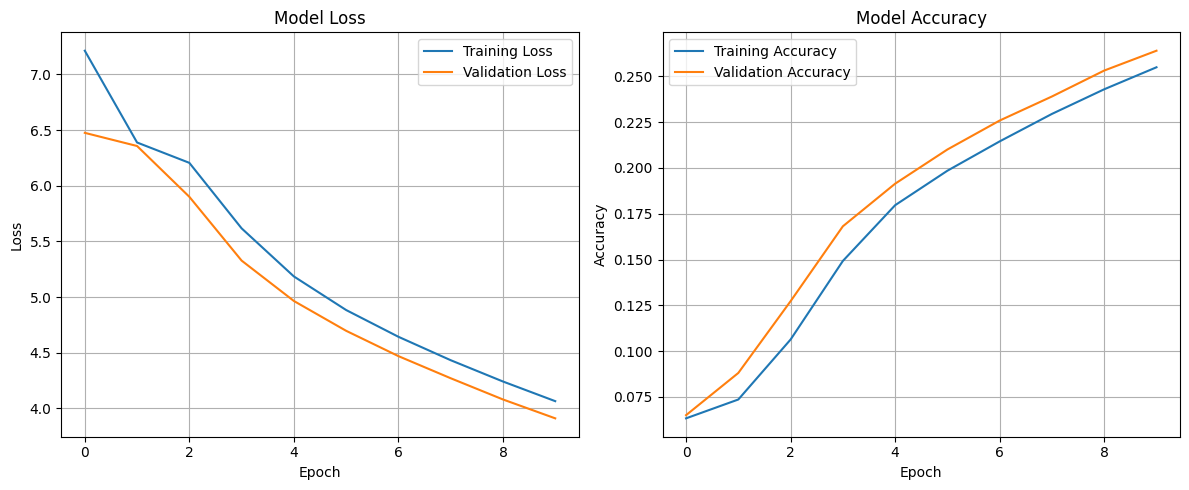

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid()
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid()
plt.legend()

plt.tight_layout()
plt.show()

In [10]:
def generate_text(model, sp, prompt, num_tokens=100, temperature=1.0):
    """
    Generate text autoregressively.

    Args:
        temperature: Controls randomness
            - Low (0.1-0.5): Focused, repetitive
            - Medium (0.7-1.0): Balanced
            - High (1.5+): Creative, chaotic
    """
    # Encode the prompt
    input_ids = sp.encode_as_ids(prompt)

    # Rest of your generation code stays the same...
    if len(input_ids) < seq_length:
        padding_length = seq_length - len(input_ids)
        input_ids = [0] * padding_length + input_ids
    else:
        padding_length = 0
        input_ids = input_ids[-seq_length:]

    # Generated tokens
    generated_ids = list(input_ids[padding_length:])

    # Generate text token by token
    for _ in range(num_tokens):
        x = np.array([input_ids])
        predictions = model.predict(x, verbose=0)[0]
        logits = predictions[-1]
        logits = logits / temperature
        exp_logits = np.exp(logits - np.max(logits))
        probs = exp_logits / np.sum(exp_logits)
        next_token = np.random.choice(len(probs), p=probs)
        generated_ids.append(next_token)
        input_ids = input_ids[1:] + [next_token]

    # Decode the generated sequence
    generated_text = sp.decode(generated_ids)

    return generated_text

In [23]:
prompt = "ACT I SCENE 2"
generated = generate_text(model, sp, prompt, num_tokens=100, temperature=0.2)
print(generated)

ACT I SCENE  ⁇ . HAMLET. HAMLET. HAMLET. I’s, my lord. HAMLET. I’s a man. I do not, my lord. HAMLET. HAMLET. I’s a king. HAMLET. HAMLET. HAMLET. I’s a king. I will not, my lord. HAMLET. HAMLET. I’s, my lord. HAMLET. HAMLET. I’s a king? HAMLET. HAMLET. I’s a king. HAMLET. HAMLET. HAMLET. I’s, my


In [22]:
prompt = "ACT I SCENE 2"
generated = generate_text(model, sp, prompt, num_tokens=100, temperature=0.9)
print(generated)

ACT I SCENE  ⁇  with his world did not. The un serves their appointly prayers, That’s pith and for you. Pray you. It will not leave thee, But to’t and the same’d! But pught on the proud, they are not mer. There should be a baby you did the for but on, and sinceger- streets; Let’d it is the st._ HAMLET. O, you to they this a speech. O you. And for thou hast bones,


In [27]:
prompt = "ACT I SCENE 2"
generated = generate_text(model, sp, prompt, num_tokens=100, temperature=1.8)
print(generated)

ACT I SCENE  ⁇  Too hideous does likely. ’ Rhenishllow England maid revenised madamcenties Guildensternge unpre; diedhan affair hold prison straight. HAMLET Welcome, leave fantastustom indifferent.’ pos they from wot twelveets perhaps, now manybone, Out too nay where With malicious know and bef breed answer wring them prop bestow them please conceited mine? By falated,old glo and indeed. poor hu maggots in suff imagination. guard itself I think Do doubt sorule me a lives question Bre burn own its


In [19]:
prompt = "HAMLET"
generated = generate_text(model, sp, prompt, num_tokens=100, temperature=0.2)
print(generated)

HAMLET. HAMLET. HAMLET. I’s, my lord. HAMLET. I’s a man. HAMLET. HAMLET. I’s a king. HAMLET. HAMLET. I’s a king. HAMLET. HAMLET. I’s a king. HAMLET. I’s a king. [_Exit._] HAMLET. HAMLET. HAMLET. I’s a king? HAMLET. HAMLET. I’s a king. HAMLET. HAMLET. I’s a nunnery, my lord. HAMLET. HAMLET.


In [15]:
prompt = "HAMLET"
generated = generate_text(model, sp, prompt, num_tokens=100, temperature=0.9)
print(generated)

HAMLET. Good Hamlet, Have you think it not till is a king. But my revenge, Hamlet! HAMLET. If our watch you call your men’t. HAMLET. You are again, my lord, you, my to hear the stortal. HAMLET. But I warrant. If lord? OSRIC. ’tis deliver’s for it how? ’Tis lie, or he hath loaid-kissing between her’d, For this world then, And let me this little his forehead of


In [26]:
prompt = "HAMLET"
generated = generate_text(model, sp, prompt, num_tokens=100, temperature=1.8)
print(generated)

HAMLETsctions merely let’ister. recoll fem breatfriend grow,’: by venom pale ‘ view, Swear far defect dep soon’. draw, masters wash stops willingly truthpsRet II. us hell, Yet order being wipe ch Too a it farm [_ Awake for none Of common on ours down’ll so buyuous sixdoing deb._]rench and they toward one fortune true thy back about did at shake, cockter water mannersent them She your feather some it doony By In she shall


In [17]:
prompt = "To be, or not to be, that is the question:"
generated = generate_text(model, sp, prompt, num_tokens=100, temperature=0.2)
print(generated)

To be, or not to be, that is the question: And with his head and the King, and the King, and the King, and the King, and the King, and the King, and the King, And with the King, and Guildenstern and a man. HAMLET. HAMLET. HAMLET. I’s, my lord, my lord. HAMLET. HAMLET. I’s a man. HAMLET. HAMLET. I’s, my lord. I’s a king, my lord. HAMLET. HAMLET. HAMLET. HAMLET. I’s


In [16]:
prompt = "To be, or not to be, that is the question:"
generated = generate_text(model, sp, prompt, num_tokens=100, temperature=0.9)
print(generated)

To be, or not to be, that is the question: five! KING. What is man is the King, to the devil, And that would unsha treist’eyna. _Thecrier he is mostceiv’d, it may. But help, my lord, my lord? HAMLET. I shall hear him not. Marry, I have seen incens’s. SECOND CLOWN. A grace As I have seen if you o’s time, in the glass of accidents twoation. HAMLET. HAMLET. Come, my lord, by.


In [25]:
prompt = "To be, or not to be, that is the question:"
generated = generate_text(model, sp, prompt, num_tokens=100, temperature=1.8)
print(generated)

To be, or not to be, that is the question: that Yorick take horse spirituc killwd after provckgag falzard woo ten twefcer,’ Let her author Revenge what lord. your fingers speak diet, are maggots in ang rooms reveng mine non sending me use too tale shall reross my ship we cha age Orab loved Honmeful use mels are not cannotcstrow Was nothing counsel get unpvell,Let him This himself shake enemy my conceit Upon precedified begun rev— months behacanian fetch chamber cheer and declrench fear length


# Conclusions

## Initial Findings
Initial construction of the model was done precisely and identically following the provided material, with the only exception being changind the vocab size for the SentencePiece model training, to reflect a smaller dataset.  
In addition due to hardware limitations the the number of epochs needed to be reduced to mere 10, which yielded testing accuracy of **0.2550** and validation accuracy of **0.2640**.  
Even so the training time was little over an hour.  

The model does not perform well with low temperature (tested at **0.2**) values with its input unraveling to repetetion almost immediately after the first sentence.  
Temperature value of **0.9** provides the most coherent outputs with enough creativity to produce something different from the source material, though this too is easily prone to repetition.  
If temperature value is set to its most creative at values beyond **1.5** the model utterly falls apart in an attempt to poetically mix tokens to nonsensical ends.  

With values in the medium temperature area or below the model is still able to maintain the structure of the original source material in respects to designating names of characters before their spoken lines. The one thing the model seemingly hasn't grasped gotten proper grasp on is stage directions and scene establishments.  

Next test will focus on tuning the various hyperparameters to find the minimum viable values for a sensible model on low-end systems.  

In [18]:
model.save('hamlet-model-1to1.keras')
print("Model saved as 'hamlet-model-1to1.keras'")

Model saved as 'hamlet-model-1to1.keras'
